Exploratory Data Analysis

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

In [5]:
# Setting style for the plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# 1. Setting paths
data_dir = "../data/ham10000"
images_dir = os.path.join(data_dir, "images")
metadata_path = os.path.join(data_dir, "HAM10000_metadata.csv")

print(f"Images folder exists: {os.path.exists(images_dir)}")
print(f"Number of images: {len([f for f in os.listdir(images_dir) if f.endswith('.jpg')])}")
print(f"Metadata exists: {os.path.exists(metadata_path)}")

Images folder exists: True
Number of images: 10015
Metadata exists: True


In [ ]:
# 2. Load metadata
df = pd.read_csv(metadata_path)
print(f"Metadata shape: {df.shape}")
print("\nFirst 5 rows")
display(df.head())

print("\nColumns")
print(df.columns.tolist())

Metadata shape: (10015, 7)

First 5 rows


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear



Columns
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


In [10]:
# 3. Class distribution (7 classes + Binary)

print("\nOriginal 7-class distribution")
print(df['dx'].value_counts())


Original 7-class distribution
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [15]:
# map to binary (standard for screening)
malignant = ['mel', 'bcc', 'akiec']
df['binary_label'] = df['dx'].apply(lambda x: 'Malignant' if x in malignant else 'Benign')

print("\nBinary class distribution (for screening):")
print(df['binary_label'].value_counts())
malignant_pct = df['binary_label'].value_counts(normalize=True)['Malignant'] * 100
print(f"Malignant percentage: {malignant_pct:.2f}%")


Binary class distribution (for screening):
binary_label
Benign       8061
Malignant    1954
Name: count, dtype: int64
Malignant percentage: 19.51%


C:\Users\Sharon\AppData\Local\Temp\ipykernel_25376\4075841917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')


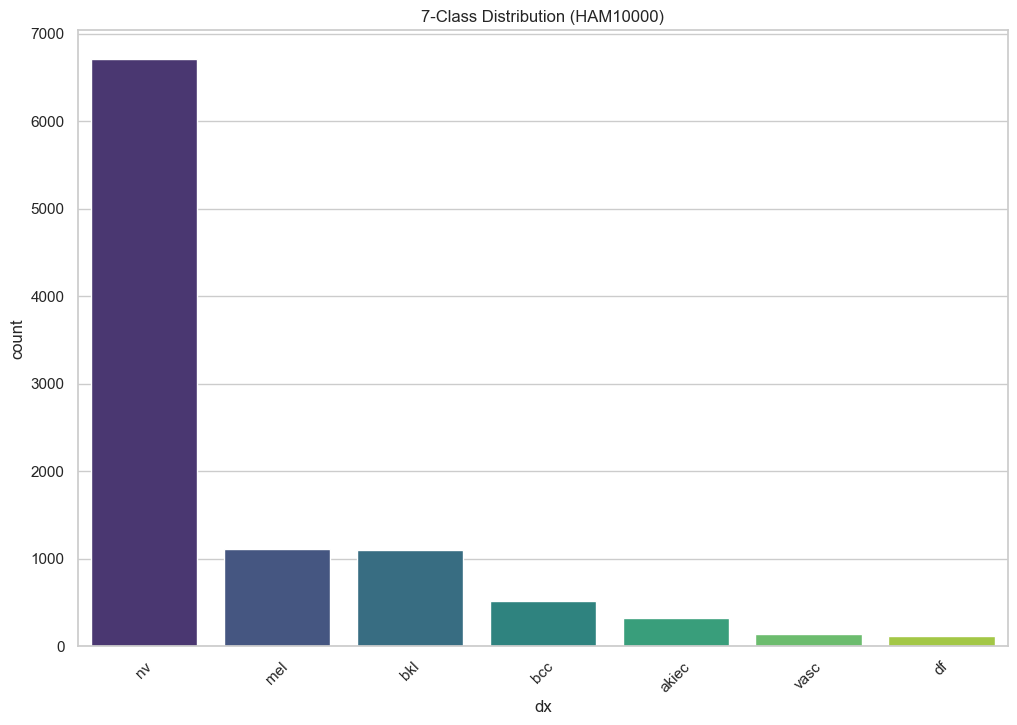

C:\Users\Sharon\AppData\Local\Temp\ipykernel_25376\4075841917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='binary_label', palette='Set1')


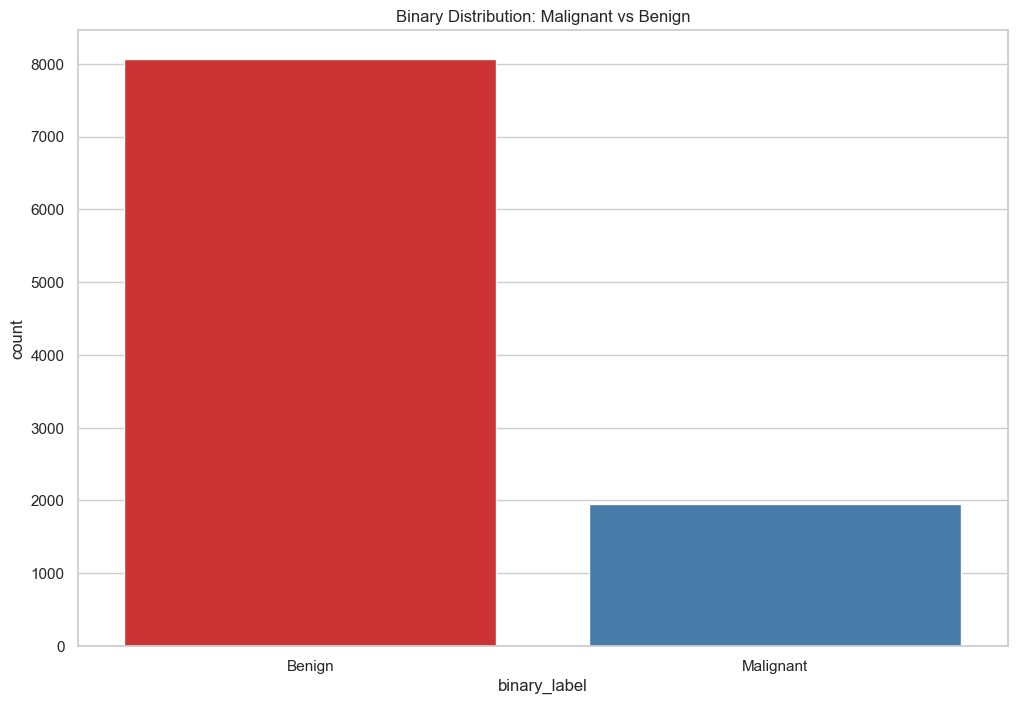

In [16]:
# Plots
plt.figure()
sns.countplot(data=df, x='dx', order=df['dx'].value_counts().index, palette='viridis')
plt.title("7-Class Distribution (HAM10000)")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.countplot(data=df, x='binary_label', palette='Set1')
plt.title("Binary Distribution: Malignant vs Benign")
plt.show()

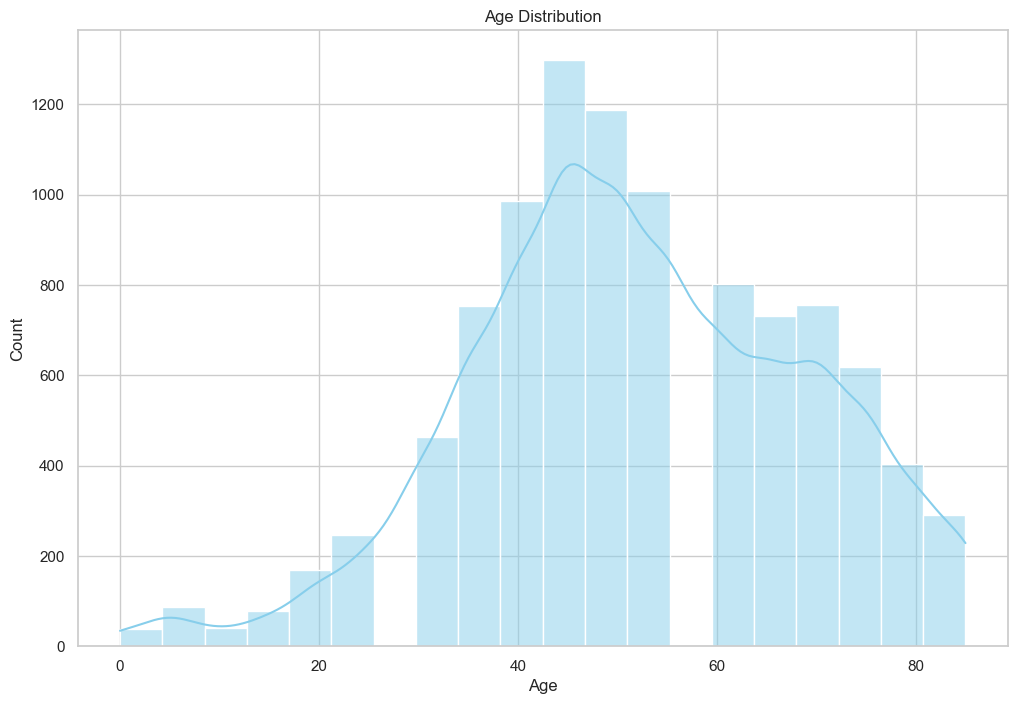

In [17]:
# 4. Metadata Analysis
# Age
plt.figure()
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

C:\Users\Sharon\AppData\Local\Temp\ipykernel_25376\536868247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='pastel')


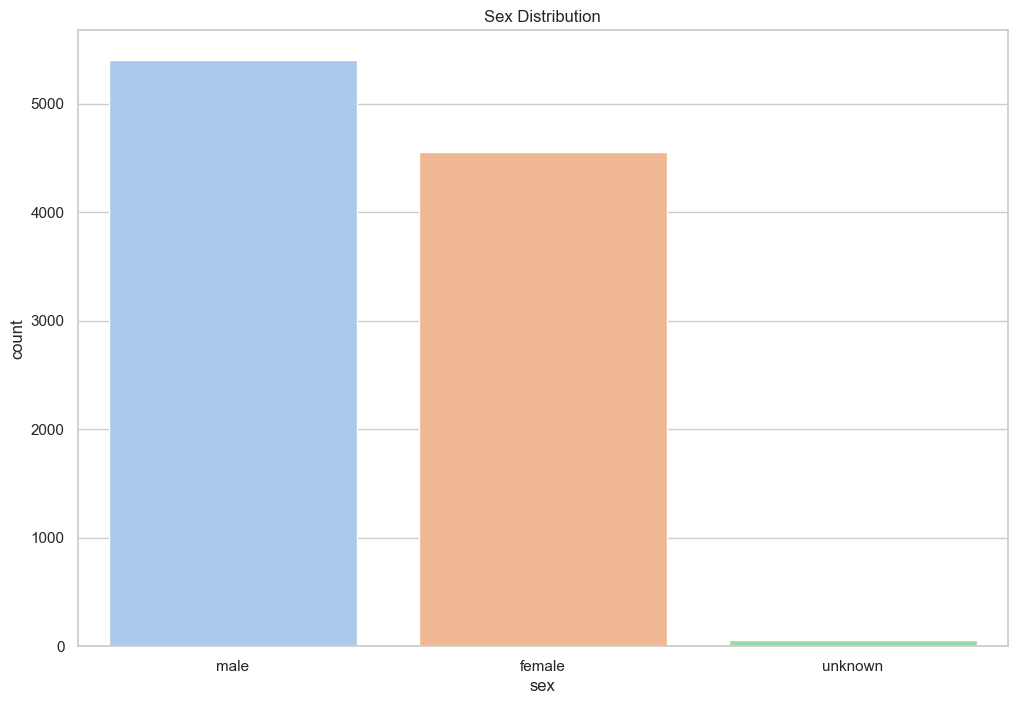

In [18]:
# Sex
plt.figure()
sns.countplot(data=df, x='sex', palette='pastel')
plt.title("Sex Distribution")
plt.show()

C:\Users\Sharon\AppData\Local\Temp\ipykernel_25376\644808689.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_loc.values, y=top_loc.index, palette='magma')


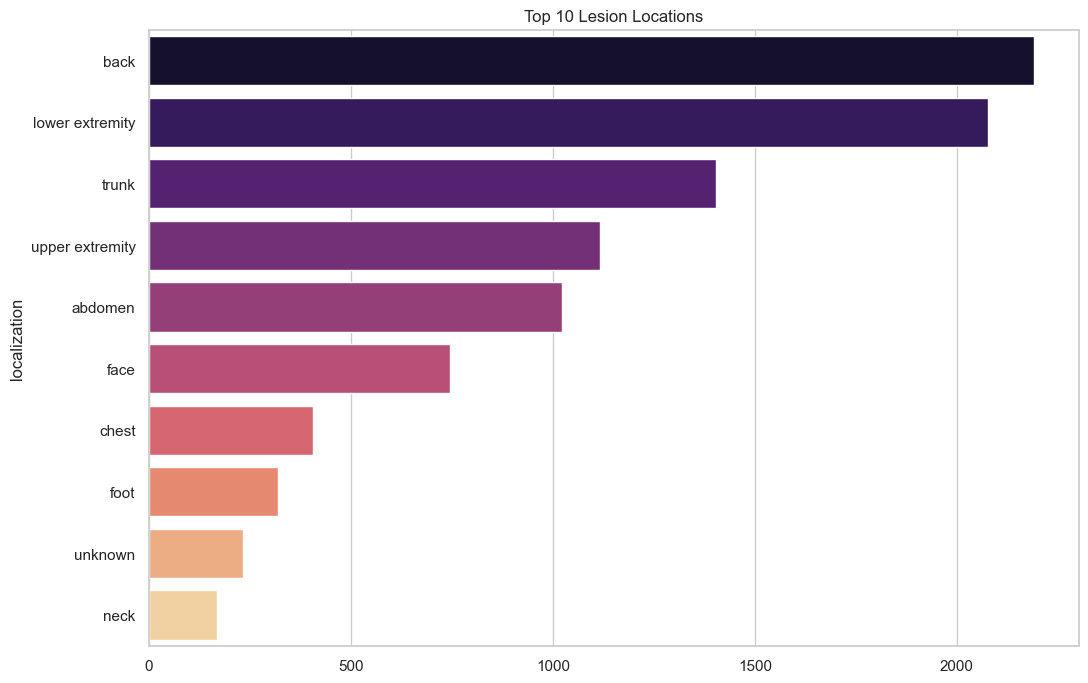

In [19]:
# body location
plt.figure()
top_loc = df['localization'].value_counts().head(10)
sns.barplot(x=top_loc.values, y=top_loc.index, palette='magma')
plt.title("Top 10 Lesion Locations")
plt.show()

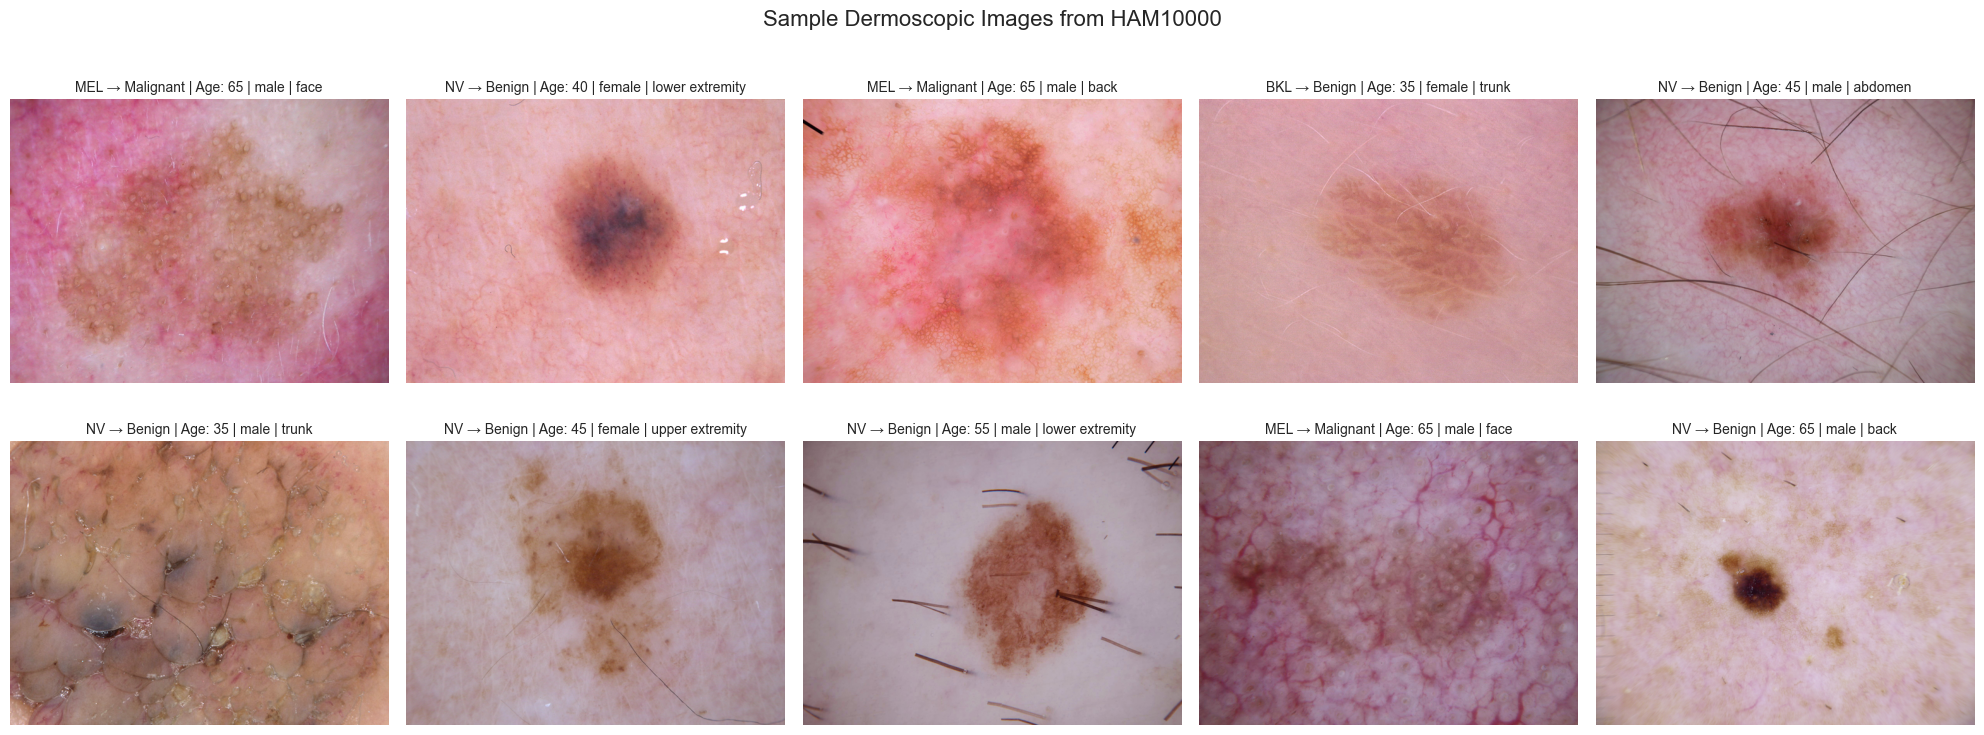

Note: These are clean dermoscopic images (magnified, uniform lighting) — contrast with Phase 2 smartphone photos!


In [20]:
# 5. Sample imgs visualization
def show_samples(df, n=10, seed=42):
    sample_df = df.sample(n=n, random_state=seed)
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.ravel()
    
    for idx, row in enumerate(sample_df.itertuples()):
        img_path = os.path.join(images_dir, row.image_id + ".jpg")
        img = Image.open(img_path)
        axes[idx].imshow(img)
        title = f"{row.dx.upper()} → {getattr(row, 'binary_label')}"
        if not np.isnan(row.age):
            title += f" | Age: {int(row.age)} | {row.sex}"
        title += f" | {row.localization}"
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')
    
    plt.suptitle("Sample Dermoscopic Images from HAM10000", fontsize=16)
    plt.tight_layout()
    plt.show()

show_samples(df, n=10)

print("Note: These are clean dermoscopic images (magnified, uniform lighting) — contrast with Phase 2 smartphone photos!")